# 決定木を用いた飲食店推薦アルゴリズムの提案

## 1. データの読み込み

In [141]:
import numpy as np
import json
from Users import GetLabels

user1_ratings, user2_ratings, user3_ratings= GetLabels.getLabels()

with open('Restaurants/Features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

feature_names = [
        "中華", "居酒屋", "ダイニングバー・バル", "和食", 
        "お好み焼き・もんじゃ", "韓国料理", "イタリアン・フレンチ", 
        "焼肉・ホルモン", "洋食", "アジア・エスニック料理", 
        "創作料理", "各国料理", "ラーメン","予算","個室", "喫煙","wifi",
        "カード", "駐車場", "総合評価"
    ]

#numpy形式に変換
features_np = np.array(features)
user1_ratings_np = np.array(user1_ratings)
user2_ratings_np = np.array(user2_ratings)
user3_ratings_np = np.array(user3_ratings)

## 2. 10フォールド交差検証
### 目的
- 決定木を用いた手法の汎化性能を評価するため.

In [157]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score
import japanize_matplotlib

 # KFoldインスタンスを初期化
kf = KFold(n_splits=10, shuffle=True, random_state=0)

# NumPy配列をリスト形式の文字列に変換する関数
def array_to_list_string(array):
    formatted_array = []
    for elem in array:
        if np.isclose(elem, np.round(elem)):
            # np.iscloseで浮動小数点数が整数に近いか確認し、整数に変換
            formatted_array.append(str(int(np.round(elem))))
        else:
            # 浮動小数点数はそのままの形式で追加
            formatted_array.append(str(elem))
    return '[' + ', '.join(formatted_array) + ']'

def crossValidation(user_ratings_np):

    # 適合率を格納するリスト
    precisions = []
    random_precisions = []

    # 再現率を格納するリスト
    recalls = []

    # フォールド番号を1から始めるためのカウンター
    fold_counter = 1

    # KFoldで分割されたインデックスを使ってループ
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成します。
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user_ratings_np[train_index], user_ratings_np[test_index]

        # 決定木の分類器を作成し、トレーニングデータにフィット
        classifier = DecisionTreeClassifier(random_state=0)
        classifier.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = classifier.predict(X_test)

        # 適合率を計算し、リストに追加
        precision = precision_score(y_test, predictions, zero_division=0)
        precisions.append(precision)
        
        # 再現率を計算し、リストに追加
        recall = recall_score(y_test, predictions, zero_division=0)
        recalls.append(recall)

        # テストセットに含まれる陽性クラスの割合を計算し、リストに追加
        positive_class_ratio = np.mean(y_test)
        random_precisions.append(positive_class_ratio)

        # 決定木のプロット
        """plt.figure(figsize=(20,10))
        plot_tree(classifier, filled=True, feature_names=feature_names)
        plt.title(f'Decision Tree for Fold {fold_counter}')
        plt.show()"""
        
        # 次のフォールドへのカウンターを増やす
        fold_counter += 1

    # 全フォールドでの平均正解率を出力
    mean_precision = np.mean(precisions)
    mean_recall = np.mean(recalls)
    mean_random_precisions = np.mean(random_precisions)
    print(f'Mean Precision across all folds: {mean_precision}')
    print(f'Mean Recall across all folds: {mean_recall}')
    print(f'Mean Random Precision across all folds: {mean_random_precisions}\n')

    return precisions, random_precisions, recalls

print("User1")
user1_precisions, random1_predisions, recalls = crossValidation(user1_ratings_np)
print("User2")
user2_precisions, random2_predisions, recalls = crossValidation(user2_ratings_np)
print("User3")
user3_precisions, random3_predisions, recalls = crossValidation(user3_ratings_np)

User1
Mean Precision across all folds: 0.6266666666666667
Mean Recall across all folds: 0.5904761904761904
Mean Random Precision across all folds: 0.44000000000000006

User2
Mean Precision across all folds: 0.9323809523809524
Mean Recall across all folds: 0.9371428571428572
Mean Random Precision across all folds: 0.48

User3
Mean Precision across all folds: 0.9800000000000001
Mean Recall across all folds: 1.0
Mean Random Precision across all folds: 0.49000000000000005



### 結果
- 全てのユーザーにおいて, ランダム手法よりも平均適合率が良いことが分かった.

## 3. シャピロ・ウィルク検定
### 目的
-  得られた適合率データ群が正規分布に従っているかどうかを確認するため.

In [161]:
from scipy import stats

def shapiro(precisions):
    # 検定の実施
    w_stat, p_value = stats.shapiro(precisions)

    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")

print("User1")
print("ランダム手法")
shapiro(random1_predisions)
print("決定木")
shapiro(user1_precisions)
print("\n")
print("ランダム手法")
shapiro(random2_predisions)
print("決定木")
shapiro(user2_precisions)
print("\n")
print("User3")
print("ランダム手法")
shapiro(random3_predisions)
print("決定木")
shapiro(user3_precisions)

User1
ランダム手法
検定結果: 統計量 = 0.9141609072685242, p値 = 0.31081217527389526
決定木
検定結果: 統計量 = 0.8970456123352051, p値 = 0.2032639980316162


ランダム手法
検定結果: 統計量 = 0.8981794714927673, p値 = 0.20921553671360016
決定木
検定結果: 統計量 = 0.6577683091163635, p値 = 0.00027216144371777773


User3
ランダム手法
検定結果: 統計量 = 0.7133795022964478, p値 = 0.0012799433898180723
決定木
検定結果: 統計量 = 0.3657206892967224, p値 = 1.0036932707180313e-07


### 結果
- 決定木モデルでは, User2, User3に対する適合率データ群のp値が0.05以下であったため, 正規分布に従っていないと言える.つまり, ノンパラメトリックな検定を使うべきだということが分かる.

## 4. ウィルコクソンの符号順位検
### 目的
- 片側検定を使って, 決定木を用いた手法とランダム手法の適合率に有意差があるかどうか(決定木を用いた手法の方が有効かどうか)を調べるため.

In [160]:
def wilcoxon(precisions, random_precisions):
    # 決定木モデルの平均適合率
    mean_precision_tree = np.mean(precisions)
    
    # ランダム手法の平均適合率の計算
    mean_precision_random = np.mean([random_precisions])

    # 検定の実施
    w_stat, p_value = stats.wilcoxon(precisions, random_precisions, alternative='greater')

    print(f"決定木モデルの平均適合率: {mean_precision_tree}")
    print(f"ランダム手法の平均適合率: {mean_precision_random}")
    print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")
    print("\n")
    
print("User1")
wilcoxon(user1_precisions, random1_predisions)
print("User2")
wilcoxon(user2_precisions, random2_predisions)
print("User3")
wilcoxon(user3_precisions, random3_predisions)

User1
決定木モデルの平均適合率: 0.6266666666666667
ランダム手法の平均適合率: 0.44000000000000006
検定結果: 統計量 = 41.0, p値 = 0.014062225058692448


User2
決定木モデルの平均適合率: 0.9323809523809524
ランダム手法の平均適合率: 0.48
検定結果: 統計量 = 55.0, p値 = 0.0009765625


User3
決定木モデルの平均適合率: 0.9800000000000001
ランダム手法の平均適合率: 0.49000000000000005
検定結果: 統計量 = 55.0, p値 = 0.0009765625




## 結果
- 全てのユーザーにおいて, p値が0.05以下であったため, 有意水準5%で決定木を用いた手法とランダム手法の適合率に有意差があった. つまり, 決定木を用いた手法の方が有効であることが分かる.

## 5. 訓練データを増やした適合率と再現率の推移
### 目的
- 訓練データを増やした際に, どの程度性能が上がるかどうかを調べる.

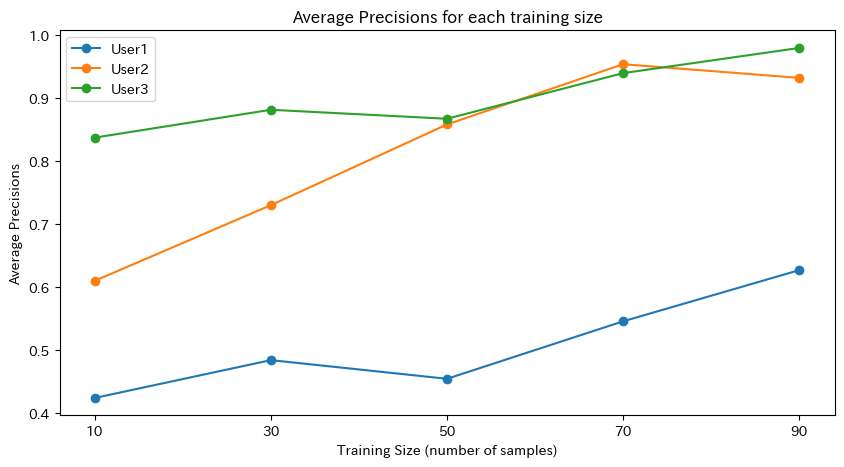

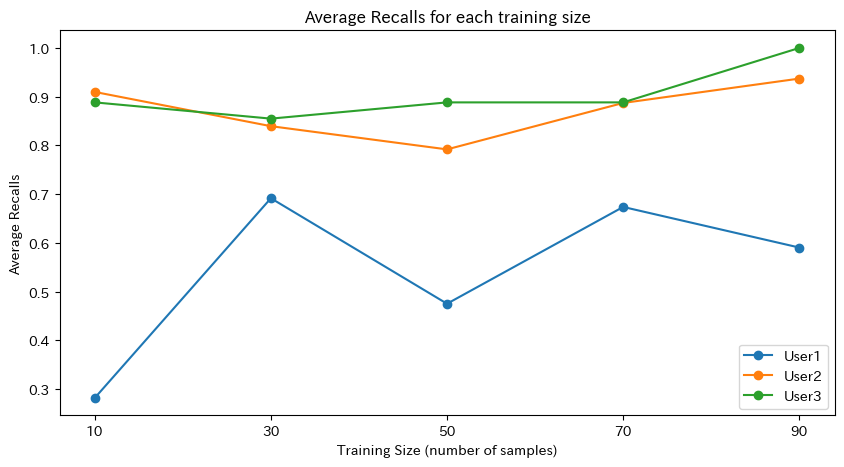

In [153]:
# 指定された訓練データのサイズ
training_sizes = [10, 30, 50, 70, 90]
def train(user_ratings_np):
    
    mean_precisions = {size: [] for size in training_sizes}
    mean_recalls = {size: [] for size in training_sizes}

    for train_index, test_index in kf.split(features_np):
        # テストデータを固定
        X_test, y_test = features_np[test_index], user_ratings_np[test_index]

        for size in training_sizes:
            # 訓練データを指定されたサイズで取得
            X_train = features_np[train_index[:size]]
            y_train = user_ratings_np[train_index[:size]]

            # モデルを訓練
            classifier = DecisionTreeClassifier(random_state=0)
            classifier.fit(X_train, y_train)

            # テストデータに対する予測
            predictions = classifier.predict(X_test)

            # 適合率を計算
            precision = precision_score(y_test, predictions, zero_division=0)
            # 再現率を計算
            recall = recall_score(y_test, predictions, zero_division=0)

            # スコアをリストに追加
            mean_precisions[size].append(precision)
            mean_recalls[size].append(recall)

    # 各訓練サイズについて平均スコアを計算
    final_precisions = [np.mean(mean_precisions[size]) for size in training_sizes]
    final_recalls = [np.mean(mean_recalls[size]) for size in training_sizes]

    return final_precisions, final_recalls

user1_final_precisions, user1_final_recalls = train(user1_ratings_np)
user2_final_precisions, user2_final_recalls = train(user2_ratings_np)
user3_final_precisions, user3_final_recalls = train(user3_ratings_np)

# 適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, user1_final_precisions, label='User1', marker='o')
plt.plot(training_sizes, user2_final_precisions, label='User2', marker='o')
plt.plot(training_sizes, user3_final_precisions, label='User3', marker='o')
plt.title('Average Precisions for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Precisions')
plt.xticks(training_sizes)
plt.legend()
plt.show()

# 再現率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, user1_final_recalls, label='User1', marker='o')
plt.plot(training_sizes, user2_final_recalls, label='User2', marker='o')
plt.plot(training_sizes, user3_final_recalls, label='User3', marker='o')
plt.title('Average Recalls for each training size')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Recalls')
plt.xticks(training_sizes)
plt.legend()
plt.show()


### 結果
- 訓練データが増えれば, 性能が上がるということが分かった

## 6. 他の手法との比較
- ロジスティック回帰を用いた手法, k-NNを用いた手法と性能を比較する

### 目的
- より分かりやすいアルゴリズムの評価にすること.

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import KFold

# モデルの初期化
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=500),
    "k-NN": KNeighborsClassifier()
}

# 結果を格納するための辞書
results = {name: {"Accuracy": [], "Precision": [], "Recall": [], "F1": []} for name in models.keys()}

# 各モデルに対して交差検証を行う
for name, model in models.items():
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user3_ratings_np[train_index], user3_ratings_np[test_index]

        # モデルを訓練
        model.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = model.predict(X_test)

        # 精度と適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        results[name]["Accuracy"].append(accuracy)
        results[name]["Precision"].append(precision)
        results[name]["Recall"].append(recall)
        results[name]["F1"].append(f1)

# 結果の表示
for name, scores in results.items():
    mean_accuracy = np.mean(scores["Accuracy"])
    mean_precision = np.mean(scores["Precision"])
    mean_recall = np.mean(scores["Recall"])
    mean_f1 = np.mean(scores["F1"])
    print(name)
    print(f"Mean Accuracy: {mean_accuracy}, Mean Precision: {mean_precision}, Mean Recall: {mean_recall}, Mean_F1: {mean_f1}\n")

Decision Tree
Mean Accuracy: 0.99, Mean Precision: 0.9800000000000001, Mean Recall: 1.0, Mean_F1: 0.9888888888888889

Logistic Regression
Mean Accuracy: 0.9, Mean Precision: 0.9273809523809524, Mean Recall: 0.8716666666666667, Mean_F1: 0.8932817182817182

k-NN
Mean Accuracy: 0.6599999999999999, Mean Precision: 0.6799999999999999, Mean Recall: 0.6416666666666667, Mean_F1: 0.6237950937950939



### 結果
- 決定木は, ロジスティック回帰やk-NNよりも, 性能が良かった.